# **P4: Recurrent Neural Networks**

### **Introduction**
In this practical project, you will implement a recurrent neural network (RNN) in PyTorch to generate Pokemon names using a character-level language model. First, you will create a class to load the dataset. Second, you will build a traditional RNN. Third, you will train this network using mini-batch gradient descent. Finally, you will use the trained model to generate new Pokemon names.

### **Objective**

The main objective of this project is to practice implementing RNNs in PyTorch, including dataset loading, implementing custom layers, training with gradient descent, and generating with language models.

### **Instructions**

After each cell of this type, there is a test cell followed by expected results, so you can check if your solution is correct. Your results might be slightly diferent from the expected results and still be correct.

### **Part 0: Import libraries**

As in the previous programming, you will import the `torch` library and other  auxiliary libraries.

In [ ]:
import torch
import sys
import random

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

### **Part 1: Loading and preprocessing the dataset**

In this first part, you will download the dataset as a txt file (pokemons.txt), which contains names of 890 Pokemon created from the first to the eighth generation of the series. Each name is separated by a \n character.

In [ ]:
!wget -O 'pokemons.txt' 'https://raw.githubusercontent.com/lesc-ufv/CCF-482/refs/heads/main/pokemons.txt'

--2026-05-25 06:05:34--  https://raw.githubusercontent.com/lesc-ufv/CCF-482/refs/heads/main/pokemons.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7603 (7.4K) [text/plain]
Saving to: ‘pokemons.txt’

pokemons.txt        100%[===================>]   7.42K  --.-KB/s    in 0s      

2026-05-25 06:05:34 (73.2 MB/s) - ‘pokemons.txt’ saved [7603/7603]



#### **1.1 Download data and create vocabulary**

Read the 'pokemons.txt' file to load all pokemon names from Generation 1 through Generation 8 in a list and produce the train/test sets randomly using a 80/20 split. Moreover, create a vocabulary (list) with all the characters in the text file sorted alphabetically. Make sure to include three extra control characters in your vocabulary: '[' (SOS), ']' (EOS), '@' (padding)

In [ ]:
random.seed(42)

# Read names
file_path = "pokemons.txt"
with open(file_path, 'r') as f:
    raw_file_content = f.read() # Read entire file content as a single string

# Create vocabulary from all unique characters in the raw file content, including special characters
unique_chars_from_file = set(raw_file_content)
control_chars = {'[', ']', '@'}
vocab_set = unique_chars_from_file.union(control_chars)
vocab = sorted(list(vocab_set)) # This will ensure '\n' is included and sorted correctly, along with '@', '[', ']'

# Process raw_text for training/testing by splitting into lines and stripping
# This raw_text will be used for shuffling and splitting
raw_text_for_dataset = [name.strip() for name in raw_file_content.splitlines() if name.strip()]

# Shuffle names
random.shuffle(raw_text_for_dataset)

# Randomly split the dataset using a 80/20 split
split_idx = int(0.8 * len(raw_text_for_dataset))
train_text = raw_text_for_dataset[:split_idx]
test_text = raw_text_for_dataset[split_idx:]


print("First 5 training examples:", train_text[:5])
print("First 5 test examples:", test_text[:5])
print("First 10 characters of vocabulary:", vocab[:10])
print("Vocabulary size", len(vocab))

First 5 training examples: ['Shellos', 'Haunter', 'Ninjask', 'Snover', 'Araquanid']
First 5 test examples: ['Pansear', 'Dracovish', 'Charmander', 'Zeraora', 'Furret']
First 10 characters of vocabulary: ['\n', ' ', "'", '-', '.', '2', ':', '@', 'A', 'B']
Vocabulary size 65


**Expected result**:

<table style="width:50%">
  <tr>
    <td> First 5 training examples </td>
    <td>['Shellos', 'Haunter', 'Ninjask', 'Snover', 'Araquanid']</td>
  </tr>
  <tr>
    <td> First 5 test examples </td>
    <td>['Pansear', 'Dracovish', 'Charmander', 'Zeraora', 'Furret']</td>
  </tr>
  <tr>
    <td> First 10 characters of vocabulary </td>
    <td>['\n', ' ', "'", '-', '.', '2', ':', '@', 'A', 'B']</td>
  </tr>
    <tr>
    <td> Vocabulary Size </td>
    <td> 65</td>
  </tr>
</table>

#### **1.2 Create a Dataset class to store the dataset**

PyTorch provides the [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) class for loading datasets from files. To create a custom dataset, you need to extend the Dataset class and implement three functions: `__init__`, `__len__`, and `__getitem__`. In this step, you will implement these three functions and some auxiliary ones to build a dataset for your Pokemon names language model.

- `__init__`:
  Initialize the dataset by creating attributes to store the names and the vocab. Add SOS/EOS tokens to each name before storing them. Morever, create mappings between characters and indices and vice versa. It is also useful to compute and store the max len of a word in the dataset.

- `one_hot_encode(ix)`:
  Create a one-hot encoded tensor for a given index.

- `encode(seq_ch)`:
  Convert a sequence of characters into a tensor of one-hot vectors.

- `decode(seq_ix)`:
  Convert a sequence of indices back into a string of characters.

- `__len__`:
  Return the total number of sequences in the dataset.

- `__getitem__(index)`:
  Process a single Pokemon name by padding (with @) to match the longest sequence length, and returning input-output tensor pairs. Use `torch.tensor()` to convert the output sequence to a tensor.

Remember that for language modeling, your input sequences (`x`) should be shifted by one character relative to your target sequences (`y`), allowing the model to predict the next character in the sequence.

In [ ]:
class CCF482Dataset(Dataset):
    def __init__(self, names, vocab):
      # create vocabulary of chars
      self.vocab = vocab
      self.ch2ix = {ch: i for i, ch in enumerate(vocab)}
      self.ix2ch = {i: ch for i, ch in enumerate(vocab)}

      # Add SOS/EOS tokens to each name and store them
      self.sequences = []
      self.max_len = 0
      for name in names:
          processed_name = '[' + name + ']'
          self.sequences.append(processed_name)
          if len(processed_name) > self.max_len:
              self.max_len = len(processed_name)

    def one_hot_encode(self, ix):
      """
      Create a one-hot encoded tensor for a given index.

      Args:
          ix (int): The index to encode.

      Returns:
          torch.Tensor: A one-hot encoded tensor of shape (vocab_size).
      """
      one_hot = torch.zeros(self.vocab_size)
      one_hot[ix] = 1
      return one_hot

    def encode(self, seq_ch):
      """
      Convert a sequence of characters into a tensor of one-hot vectors.

      Args:
          seq_ch (str): A string representing the sequence of characters to encode.

      Returns:
          torch.Tensor: A tensor of one-hot vectors representing the input sequence.
      """
      encoded_sequence = []
      for ch in seq_ch:
          encoded_sequence.append(self.one_hot_encode(self.ch2ix[ch]))
      return torch.stack(encoded_sequence)

    def decode(self, seq_ix):
      """
      Convert a sequence of indices back into a string of characters.

      Args:
          seq_ix (list): A list of indices representing the characters in the sequence.

      Returns:
          str: The decoded string of characters.
      """
      return ''.join([self.ix2ch[ix.item()] if isinstance(ix, torch.Tensor) else self.ix2ch[ix] for ix in seq_ix])

    def __len__(self):
      """
      Get the total number of sequences in the dataset.

      Returns:
          int: The total number of sequences in the dataset.
      """
      return len(self.sequences)

    def __getitem__(self, index):
      """
      Get a single sample from the dataset.

      Args:
          index (int): Index of the sample to retrieve.

      Returns:
          tuple: A tuple containing the input tensor x and the target tensor y.
      """
      name = self.sequences[index]
      # Pad the name with '@' to max_len
      padded_name = name + '@' * (self.max_len - len(name))

      # Input sequence (x) - one-hot encoded
      x = self.encode(padded_name)

      # Target sequence (y) - shifted indices
      y_indices = [self.ch2ix[ch] for ch in padded_name[1:]]
      # Append padding index for the last character of x to match length
      y_indices.append(self.ch2ix['@'])
      y = torch.tensor(y_indices, dtype=torch.long)

      return x, y

    @property
    def vocab_size(self):
      """
      Get the size of the vocabulary.

      Returns:
          int: The size of the vocabulary.
      """
      return len(self.vocab)

In [ ]:
train_dataset = CCF482Dataset(train_text, vocab)
test_dataset = CCF482Dataset(test_text, vocab)

print("Train vocabulary size:", train_dataset.vocab_size)
print("Test vocabulary size:", test_dataset.vocab_size)

print("Train max sequence length:", train_dataset.max_len)
print("Test max sequence length:", test_dataset.max_len)

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))

Train vocabulary size: 65
Test vocabulary size: 65
Train max sequence length: 14
Test max sequence length: 13
Train dataset size: 712
Test dataset size: 178


**Expected result**:

<table style="width:50%">
  <tr>
    <td> Train vocabulary size </td>
    <td>65</td>
  </tr>
  <tr>
    <td> Test vocabulary size </td>
    <td>65</td>
  </tr>
  <tr>
    <td> Train max sequence length </td>
    <td>14</td>
  </tr>
  <tr>
    <td> Test max sequence length </td>
    <td>13</td>
  </tr>
  <tr>
    <td> Train dataset size </td>
    <td>712</td>
  </tr>
    <tr>
    <td> Test dataset size </td>
    <td>178</td>
  </tr>
</table>

#### **1.3 Visualization of examples**

If you loaded the data correctly, you can use the code below to visualize examples from the dataset.

In [ ]:
x = train_dataset.sequences[0]
x_encoded, y = train_dataset[0]
print("x0", x)
print("x0_encoded size", x_encoded.size())
print("y", y)

x0 [Shellos]
x0_encoded size torch.Size([14, 65])
y tensor([26, 43, 40, 47, 47, 50, 54, 35,  7,  7,  7,  7,  7,  7])


**Expected result**:

<table style="width:50%">
  <tr>
    <td>x0</td>
    <td>[Shellos]</td>
  </tr>
  <tr>
    <td>x0 encoded size</td>
    <td>[13, 65]</td>
  </tr>
  <tr>
    <td> y </td>
    <td>[26, 43, 40, 47, 47, 50, 54, 35,  7,  7,  7,  7,  7]</td>
  </tr>
</table>

#### **1.4 Create a DataLoader to iterate through examples**

 Create a `train_loader` and a `test_loader` using PyTorch's [DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) for the training and test set. Configure both of them with:
- batch_size = 32
- drop_last = True (to remove the last potentially incomplete minibatch)

Make sure to set shuffle parameter to True in your training data loader. You don't need to shuffle the test data loader.


In [ ]:
# Create training data loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)

# Create test data loader
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=True)

In [ ]:
torch.manual_seed(1)

# Assuming the variable train_loader have been defined in the previous cell.
train_x_batch, train_y_batch = next(iter(train_loader))
test_x_batch, test_y_batch = next(iter(test_loader))

print("A single training batch size: ", train_x_batch.size())
print("A single test batch size: ", test_x_batch.size())

print("Train Sanity check: ", train_x_batch[0][1])
print("Test Sanity check: ", test_x_batch[0][1])

A single training batch size:  torch.Size([32, 14, 65])
A single test batch size:  torch.Size([32, 13, 65])
Train Sanity check:  tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Test Sanity check:  tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


**Expected result**:

<table style="width:50%">
  <tr>
    <td> Single training batch size </td>
    <td>[32, 13, 65]</td>
  </tr>
  <td> Single test batch size </td>
    <td>[32, 12, 65]</td>
  </tr>
  <tr>
    <td> Train Sanity check </td>
    <td>[0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]
    </td>
  </tr>
    <tr>
    <td> Test Sanity check </td>
    <td>[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]
    </td>
  </tr>
</table>

## **Part 2: Recurrent Neural Network**

Now that you have a dataset ready for training, it's time to create your RNN.

#### **2.1 Recurrent Hidden Layer**

The first step to create your RNN is to implement a class that extends `torch.nn.Module` with `__init__` to initialize the RNN weights and `forward(x)` for input propagation.

- Weight initialization (`__init__`):
  Use [`torch.nn.Parameter`](https://pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html) to initialize the RNN weights:
  - `self.Wx`: input weights
  - `self.Wh`: hidden state weights
  - `self.b`: bias
  
  Initialize weights with small random values (`torch.randn * 0.01`) and bias with zeros (`torch.zeros`).

- Forward propagation (`forward(x)`):
  Implement the RNN forward pass (for the hidden layear only) following this equation:

  \begin{align}
    h^{<t>} &= tanh(W_{h} h^{<t-1>} + W_{x}x^{<t>} + b) \\
  \end{align}
  where:
  - x_t is the input at time t
  - h_t is the hidden state at time t
  - Wx, Wh, and b are the learnable parameters

  Remember to:
  1. Handle the initial hidden state case
  2. Process input sequence from left to right
  3. Use `torch.cat` to combine hidden states
  4. Use `permute` to arrange the output tensor in the format (batch_size, seq_len, hidden_size)

In [ ]:
class CCF482RNNLayer(torch.nn.Module):
    def __init__(self, input_size, hidden_size):
        """
        Initialize the RNN layer.

        Args:
            input_size (int): The number of expected features in the input x.
            hidden_size (int): The number of features in the hidden state h.
        """
        super(CCF482RNNLayer, self).__init__()
        self.hidden_size = hidden_size

        # Initialize weights with small random values and bias with zeros
        self.Wx = torch.nn.Parameter(torch.randn(hidden_size, input_size) * 0.01)
        self.Wh = torch.nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b = torch.nn.Parameter(torch.zeros(hidden_size))

    def forward(self, x, h_prev):
        """
        Forward pass of the entire RNN.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, sequence_length, input_size).
            h_prev (torch.Tensor): Initial hidden state tensor of shape (batch_size, hidden_size).

        Returns:
            outputs (torch.Tensor): Sequence of hidden states for each timestep.
            h_t: The final hidden state after processing the entire sequence x.
        """
        batch_size, sequence_length, _ = x.size()

        # If h_prev is None, initialize it with zeros
        if h_prev is None:
            h_prev = torch.zeros(batch_size, self.hidden_size, device=x.device)

        hidden_states = []
        for t in range(sequence_length):
            x_t = x[:, t, :]
            h_t = torch.tanh(torch.matmul(x_t, self.Wx.T) + torch.matmul(h_prev, self.Wh.T) + self.b)
            hidden_states.append(h_t)
            h_prev = h_t

        outputs = torch.stack(hidden_states, dim=1) # Shape: (batch_size, sequence_length, hidden_size)

        return outputs, h_prev

In [ ]:
torch.manual_seed(1)

rnn_layer = CCF482RNNLayer(input_size=train_dataset.vocab_size, hidden_size=10)
x, y = train_dataset[0]

with torch.no_grad():
  outputs, hidden = rnn_layer(x.unsqueeze(0), None)

print("Outputs size:", outputs.size())
print("Last hidden state:", hidden)

Outputs size: torch.Size([1, 14, 10])
Last hidden state: tensor([[-0.0159, -0.0070, -0.0190, -0.0087,  0.0080, -0.0072, -0.0066, -0.0208,
         -0.0029,  0.0080]])


**Expected result**:

<table style="width:50%">
  <tr>
    <td> **Outputs size** </td>
    <td>[1, 13, 10]</td>
  </tr>
  <tr>
    <td> **Last hidden state** </td>
    <td>[[[0.0164, 0.0001, -0.0067, -0.0022, -0.0096, -0.0086, -0.0046,
          -0.0056, 0.0040, -0.0098]]]</td>
  </tr>
</table>

####**2.2 Language Model**

Use your recurrent layer to define your language model. Extend `torch.nn.Module` to create a language model that can predict the next character in a sequence.

Your model should contain:
- A recurrent layer (from your previous implementation)
- A fully connected layer using [`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)

The architecture should:
- Take one-hot encoded characters as input (size of vocabulary)
- Process them through the RNN layer (produces hidden states)
- Pass the hidden states through a linear layer to predict the next character
- Return both the predictions and the final hidden state

Remember that the linear layer should process the RNN output for each timestep to make character predictions.

Parameters:
- Input size: vocab_size
- Hidden size: as specified by hidden_size parameter
- Output size: vocab_size (to predict probabilities for each possible character)

In [ ]:
class CCF482RNNLanguageModel(torch.nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super(CCF482RNNLanguageModel, self).__init__()
        self.rnn_layer = CCF482RNNLayer(vocab_size, hidden_size)
        self.linear_layer = torch.nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        # Pass input through the RNN layer
        rnn_outputs, final_hidden_state = self.rnn_layer(x, hidden)
        # Pass RNN outputs through a linear layer to get predictions
        predictions = self.linear_layer(rnn_outputs)
        return predictions, final_hidden_state

In [ ]:
torch.manual_seed(1)

x, y = train_dataset[0]

language_model = CCF482RNNLanguageModel(vocab_size=train_dataset.vocab_size, hidden_size=10)
with torch.no_grad():
  outputs, hidden = language_model(x.unsqueeze(0), None)

print("Output size:", outputs.size())
print("Hidden state:", hidden)

Output size: torch.Size([1, 14, 65])
Hidden state: tensor([[-0.0159, -0.0070, -0.0190, -0.0087,  0.0080, -0.0072, -0.0066, -0.0208,
         -0.0029,  0.0080]])


**Expected result**:

<table style="width:50%">
  <tr>
    <td> Output size </td>
    <td>[1, 13, 65]</td>
  </tr>
  <tr>
    <td> Hidden state </td>
    <td>[[[0.0164, 0.0001, -0.0067, -0.0022, -0.0096, -0.0086, -0.0046,
          -0.0056, 0.0040, -0.0098]]]</td>
  </tr>
</table>

## **Part 3: Training with Mini-batch Gradient Descent**

In the third step, you will write the training loop for your Pokemon names language model.

####**3.1 Calculate loss on test set**

Before writting the training loop, you will need to implement a function to compute the loss on the test set, so you can store the test error over the training epochs. To compute the loss, run the forward pass for each mini-batch of your test set and sum the losses of each mini-batch. Return the average loss by dividing this sum by the number of mini-batches in the test set.

In [ ]:
def test(model, test_loader):
  """
  Evaluate a given model on a dataset stored in dataloader

  Arguments:
  - model (torch.nn.Module): A language model to evaluate.
  - test_loader (torch.utils.data.DataLoader): DataLoader for the test dataset.
  """
  model.eval()
  total_loss = 0
  criterion = torch.nn.CrossEntropyLoss()

  with torch.no_grad():
    for x_batch, y_batch in test_loader:
      hidden = None # Reset hidden state for each new sequence in the batch
      predictions, hidden = model(x_batch, hidden)

      # Reshape predictions and y_batch for CrossEntropyLoss
      # predictions shape: (batch_size, sequence_length, vocab_size)
      # y_batch shape: (batch_size, sequence_length)
      loss = criterion(predictions.permute(0, 2, 1), y_batch)
      total_loss += loss.item()

  return total_loss / len(test_loader)

In [ ]:
torch.manual_seed(1)

language_model = CCF482RNNLanguageModel(vocab_size=train_dataset.vocab_size, hidden_size=10)

loss = test(language_model, test_loader)
print("Test loss:", loss)

Test loss: 4.246804904937744


**Expected result**:

<table style="width:50%">
  <tr>
    <td> Test Loss </td>
    <td>4.234122180938721</td>
  </tr>
</table>

####**3.2 Training loop**

The training loop is similar to the previous project, with two key differences:

1. Initialize the hidden vector as `None` at the start of each mini-batch (since names are independent sequences)
2. Add gradient clipping using [`torch.nn.utils.clip_grad_norm_`](https://pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html) with a maximum norm of 5 before the optimizer step

Training specifications:
- Number of epochs: 100
- Print loss every 10 epochs
- Use provided dataloader for mini-batches
- Reset hidden state for each mini-batch
- Clip gradients before weight updates

Remember to:
- Define your loss function and optimizer
- Track and store training losses
- Apply gradient clipping before optimizer.step()

In [ ]:
def optimize(model, train_loader, test_loader, vocab_size, learning_rate=0.001, num_epochs=100, outpath='ccf482net.pth'):
  """
  Train a given model on a dataset stored in dataloader

  Arguments:
  - model (torch.nn.Module): A language model to train.
  - train_loader (torch.utils.data.DataLoader): DataLoader for the training dataset.
  - test_loader (torch.utils.data.DataLoader): DataLoader for the test dataset.
  - vocab_size (int): Size of the vocabulary.
  - learning_rate (float): Learning rate for the optimizer.
  - num_epochs (int): Number of training epochs.
  - outpath (str): Path to save the trained model.
  """
  # Lists to store the average training and testing errors
  train_losses = []
  test_losses = []

  # Define loss function and optimizer
  criterion = torch.nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  for epoch in range(1, num_epochs + 1):
    model.train() # Set model to training mode
    total_train_loss = 0
    for x_batch, y_batch in train_loader:
      hidden = None # Reset hidden state for each new sequence in the batch

      # Forward pass
      predictions, hidden = model(x_batch, hidden)

      # Calculate loss
      loss = criterion(predictions.permute(0, 2, 1), y_batch)

      # Backward and optimize
      optimizer.zero_grad()
      loss.backward()

      # Gradient clipping
      torch.nn.utils.clip_grad_norm_(model.parameters(), 5)

      optimizer.step()
      total_train_loss += loss.item()

    # Calculate average training loss for the epoch
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluate on test set
    avg_test_loss = test(model, test_loader)
    test_losses.append(avg_test_loss)

    # Print loss every 10 epochs
    if epoch % 10 == 0:
      print(f"Epoch {epoch}/{num_epochs}: Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

  # Save the trained model
  torch.save(model.state_dict(), outpath)

  return train_losses, test_losses

In [ ]:
torch.manual_seed(1)

# Create the model
model = CCF482RNNLanguageModel(train_dataset.vocab_size, hidden_size=50)

# Train the model
train_losses, test_losses = optimize(model, train_loader, test_loader, train_dataset.vocab_size, num_epochs=100)

Epoch 10/100: Train Loss: 2.0974, Test Loss: 2.2649
Epoch 20/100: Train Loss: 1.7991, Test Loss: 1.9853
Epoch 30/100: Train Loss: 1.6374, Test Loss: 1.8293
Epoch 40/100: Train Loss: 1.5699, Test Loss: 1.7557
Epoch 50/100: Train Loss: 1.5329, Test Loss: 1.7221
Epoch 60/100: Train Loss: 1.5032, Test Loss: 1.6992
Epoch 70/100: Train Loss: 1.4845, Test Loss: 1.6853
Epoch 80/100: Train Loss: 1.4653, Test Loss: 1.6754
Epoch 90/100: Train Loss: 1.4523, Test Loss: 1.6700
Epoch 100/100: Train Loss: 1.4339, Test Loss: 1.6656


**Expected result**:
<table>
    <tr>
        <td> Epoch 10/200</td>
        <td> Train Loss: 2.2040681080384688, Test Loss: 2.40151629447937</td>
    </tr>
    <tr>
         <td> Epoch 20/200</td>
        <td> Train Loss: 1.9249448776245117, Test Loss: 2.1330626726150514</td>
    </tr>
    <tr>
        <td> ...</td>
        <td> ... </td>
        <td> ... </td>
    </tr>
    <tr>
         <td> Epoch 100/100</td>
        <td> Train Loss: 1.5415673093362288, Test Loss: 1.804492712020874</td>
    </tr>
</table>

####**3.3 Plot learning curve**

Plot the training and test learning curves using matplotlib.

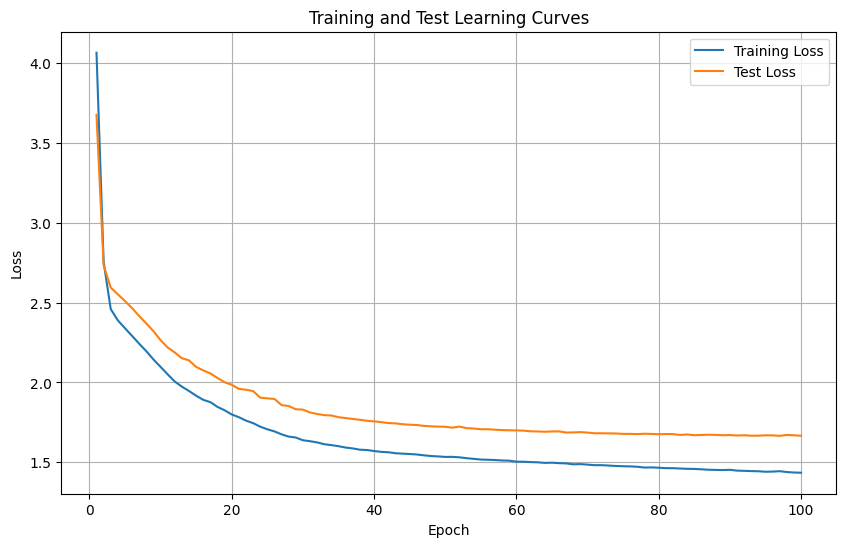

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
plt.plot(range(1, len(test_losses) + 1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Learning Curves')
plt.legend()
plt.grid(True)
plt.show()

**Expected result**

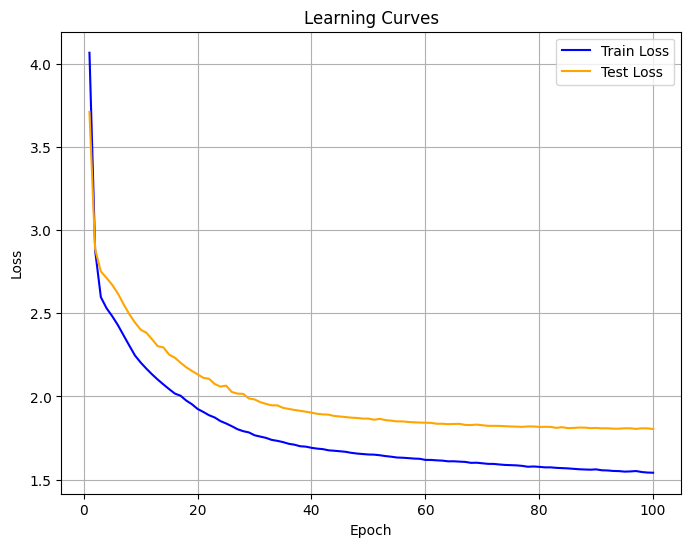

## **Part 4: Sampling from the Language Model**

In the fourth and final part, you will use your trained language model to generate new Pokemon names.

To generate names:

1. Start with a prime string and feed it through the model character by character using the `encode` function from `CCF482Dataset` to create one-hot vectors.

2. For character generation:
   - Apply [`torch.nn.functional.softmax`](https://pytorch.org/docs/stable/generated/torch.nn.functional.softmax.html) to the model output to get probabilities
   - Use [`torch.multinomial`](https://pytorch.org/docs/stable/generated/torch.multinomial.html) for sampling the next character index
   - Convert the index back to a character using the `decode` function

3. Generation loop:
   - Continue generating characters until you encounter the end token `"]"`
   - Feed each generated character back as input for the next prediction
   - Collect all generated characters to form the final name

Parameters to use:
- Prime string: starting sequence for generation
- Temperature: controls randomness in generation (if implemented)
- Model should be in evaluation mode during generation

In [ ]:
import torch.nn.functional as F

def generate(model, text_dataset, prime="["):
  """
  Generate a pokemon name with a given model and a prime sequence

  Arguments:
  - model (torch.nn.Module): A trained language model to sample names from.
  - text_dataset (torch.utils.data.Dataset): A language model dataset to access to encode/decode pokemon names
  - prime (str): A prime sequence to start the generation process.

  Returns:
  - pokemon_name (str): a pokemon generated name.
  """
  model.eval()
  hidden = None
  generated_name = prime
  max_generation_length = 20 # Limit length to prevent infinite loops

  with torch.no_grad():
    for _ in range(max_generation_length):
      # Get the last character of the generated sequence
      last_char = generated_name[-1]

      # Encode the last character (input for the model)
      input_tensor = text_dataset.encode(last_char).unsqueeze(0) # Add batch dimension

      # Forward pass through the model
      output, hidden = model(input_tensor, hidden)

      # Get probabilities for the next character
      # output shape: (batch_size, sequence_length, vocab_size)
      # We are interested in the last timestep's prediction: output[0, -1, :]
      probabilities = F.softmax(output[0, -1, :], dim=0)

      # Sample the next character index
      next_char_ix = torch.multinomial(probabilities, 1).item()

      # Decode the index back to a character
      next_char = text_dataset.decode([next_char_ix])

      # Append to generated name
      generated_name += next_char

      # Stop if EOS token is generated
      if next_char == ']':
        break

  return generated_name

In [ ]:
torch.manual_seed(1)

# Load trained model
model = CCF482RNNLanguageModel(train_dataset.vocab_size, hidden_size=50)
model.load_state_dict(torch.load('ccf482net.pth'))

n_pokemons = 10
for i in range(n_pokemons):
  p = generate(model, train_dataset)
  print(p)

[Merans]
[Niew]
[Cipire]
[Anzancor]
[Xwart]
[Schapilu]
[Medustoas]
[Rymoun]
[Gritoyk]
[Stascyund]


**Expected result**:
<table>
    <tr>
        <td> [eerans]</td>
    </tr>
    <tr>
        <td> [Niew]</td>
    </tr>
    <tr>
        <td> [Cipire]</td>
    </tr>
    <tr>
        <td> [Alzancor]</td>
    </tr>
    <tr>
        <td> [twaré]</td>
    </tr>
    <tr>
        <td> [Schapilu]</td>
    </tr>
    <tr>
        <td> [xedubaon]</td>
    </tr>     
    <tr>
        <td> [Woymou]</td>
    </tr>
    <tr>
        <td> [Arvitoy]</td>
    </tr>   
    <tr>
        <td> [earascyund]</td>
    </tr>                    
</table>

Congratulations! Your language model is ready

1.   Item da lista
2.   Item da lista

to generate new Pokemon!

## **Part 6: Generate your own Pokemon**

Use the generate function to create a list of Pokemon names. When you find a name you like, use the Bing Image Generator to illustrate your new Pokemon:

https://www.bing.com/create

Tip: use a prompt like "Generate a fake pokemon named [POKEMON_NAME] in the style of the [GENERATION NUMBER] generation."

Expected Result:

Generate a fake pokemon named Heix in the style of the 1st generation.

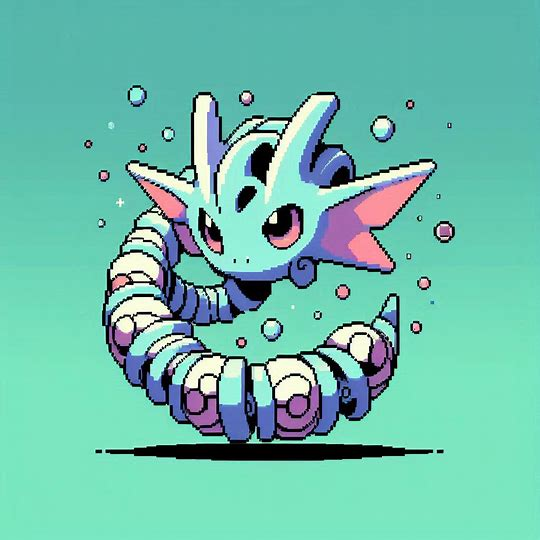

Teste: 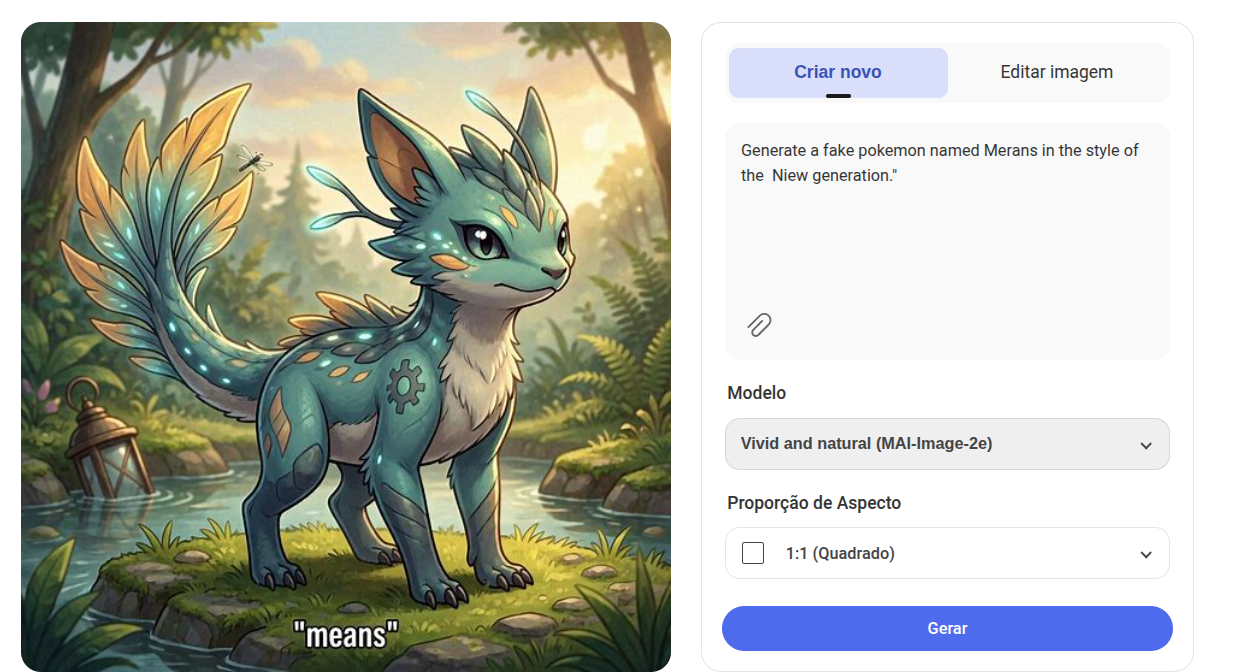

Meu pokemon Merans do tipo água

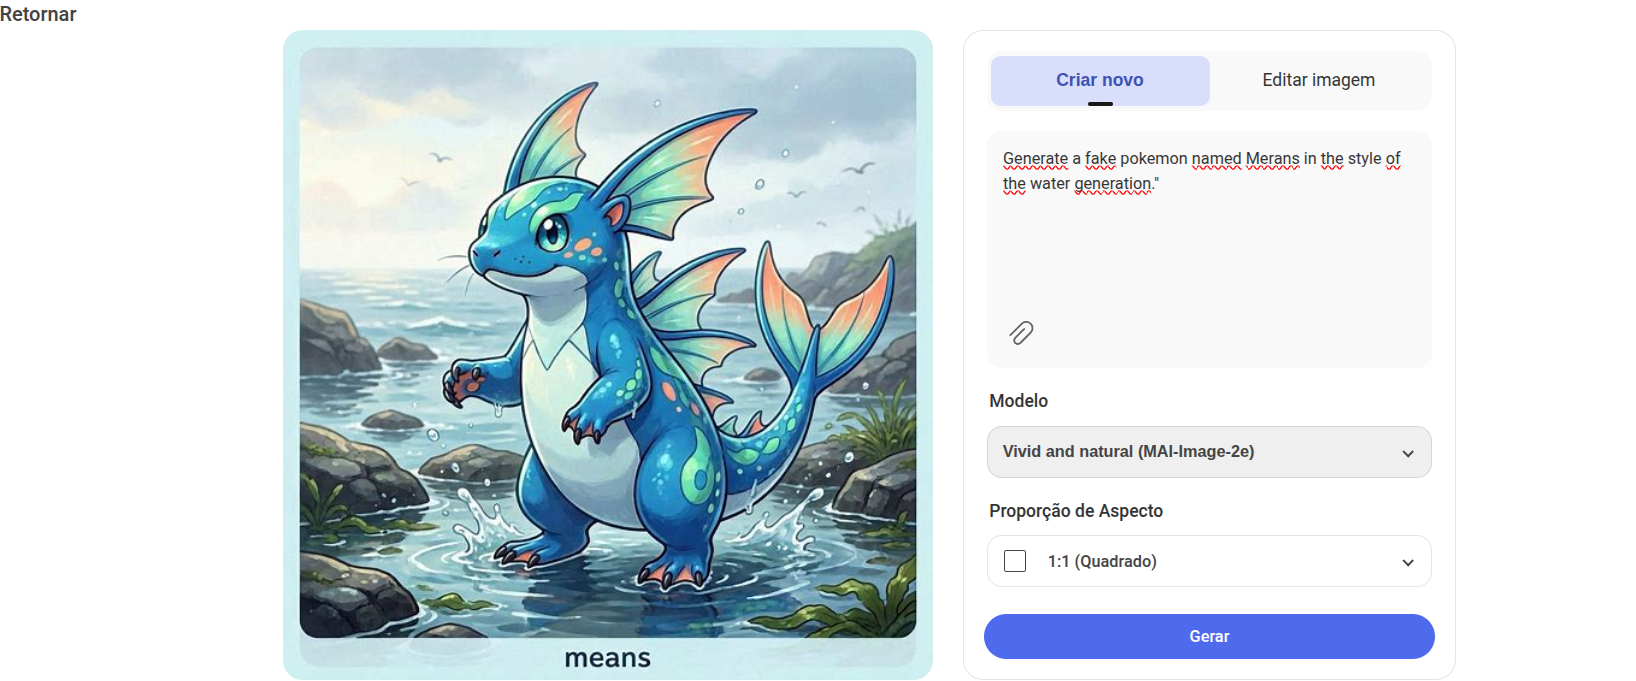

## **Part 7: Challenge (Optional)**

Create an LSTM or a GRU network to build a character-level language model to generate novels like Machado de Assis. You will have access to the training and validation sets, but not to the test set. The model with lower error on the test set will get 1 extra point! You can try any idea we've seen in the course so far to build your model. Report the results with a plot containing the training and validation learning curves, as you did before with the pokemon dataset. Also show the results of some generated novel you were able to produce with your model.

## **Part 8: Challenge Accepted**


Para dar início ao treinamento da minha rede neural, a primeira etapa que executo é a aquisição do nosso corpus de texto. Neste trecho de código, utilizo a biblioteca requests para fazer o download direto das obras de Machado de Assis que deixei hospedadas no meu repositório do GitHub. Criei a função baixar_texto_bruto para automatizar esse processo: ela acessa a URL, verifica se a conexão foi bem-sucedida e salva o conteúdo em arquivos .txt locais, garantindo a codificação utf-8 para preservarmos toda a rica acentuação da língua portuguesa.

In [ ]:
import requests

def baixar_texto_bruto(url, nome_arquivo):
    resposta = requests.get(url)
    resposta.raise_for_status() # Lanca uma excecao para erros HTTP
    with open(nome_arquivo, 'w', encoding='utf-8') as f:
        f.write(resposta.text)
    print(f"Baixado '{nome_arquivo}' de {url}")

# URLs brutas corretas para os arquivos de texto
url_treino = 'https://raw.githubusercontent.com/JhonataMiranda/CCF482/main/machado_train.txt'
url_validacao = 'https://raw.githubusercontent.com/JhonataMiranda/CCF482/main/machado_valid.txt'

# Baixar os arquivos
baixar_texto_bruto(url_treino, 'machado_treino.txt')
baixar_texto_bruto(url_validacao, 'machado_validacao.txt')

Baixado 'machado_treino.txt' de https://raw.githubusercontent.com/JhonataMiranda/CCF482/main/machado_train.txt
Baixado 'machado_validacao.txt' de https://raw.githubusercontent.com/JhonataMiranda/CCF482/main/machado_valid.txt


Com os arquivos salvos no ambiente do Colab, o meu próximo passo é carregá-los para a memória do Python. Neste bloco, eu abro os textos de treino e validação e imprimo uma pequena amostra na tela para garantir que a leitura foi feita corretamente. Além disso, junto todo o texto para extrair o nosso 'Vocabulário' — ou seja, uma lista contendo todos os caracteres únicos que o Machado de Assis utilizou em suas obras. É a partir desse vocabulário que o modelo aprenderá a ler e escrever.

In [ ]:
caminho_arquivo_treino = "machado_treino.txt"
with open(caminho_arquivo_treino, 'r', encoding='utf-8') as arquivo:
  texto_treino_machado = arquivo.read()

caminho_arquivo_validacao = "machado_validacao.txt"
with open(caminho_arquivo_validacao, 'r', encoding='utf-8') as arquivo:
  texto_validacao_machado = arquivo.read()

# Vamos inspecionar o conteudo para garantir que nao e HTML
print("--- Amostra do Texto de Treino ---")
print(texto_treino_machado[:500])
print("\n--- Amostra do Texto de Validacao ---")
print(texto_validacao_machado[:500])

# Tambem, vamos criar um texto combinado para criacao do vocabulario, se necessario.
# Para modelo de linguagem a nivel de caractere, precisamos de todos os caracteres possiveis.
texto_completo_machado = texto_treino_machado + texto_validacao_machado

# Cria vocabulario a partir de todos os caracteres unicos
caracteres_unicos = sorted(list(set(texto_completo_machado)))
# Adiciona tokens especiais se necessario, ex: '[SOS]', '[EOS]', '[PAD]'
# Por enquanto, vamos usar apenas os caracteres unicos encontrados no texto.
# Podemos adicionar tokens especiais depois ao processar sequencias.
vocabulario_machado = caracteres_unicos

print(f"\nTamanho do Vocabulario Machado: {len(vocabulario_machado)}")
print(f"Amostra do Vocabulario Machado: {vocabulario_machado[:50]}")

--- Amostra do Texto de Treino ---
Casa Velha

CAPÍTULO PRIMEIRO
ANTES E DEPOIS DA MISSA
Aqui está o que contava, há muitos anos, um velho cônego da Capela
Imperial:
— Não desejo ao meu maior inimigo o que me aconteceu no mês de
abril de 1839. Tinha-me dado na cabeça escrever uma obra política, a
história do reinado de D. Pedro I. Até então esperdiçara algum talento
em décimas e sonetos, muitos artigos de periódicos, e alguns sermões,
que cedia a outros, depois que reconheci que não tinha os dons
indispensáveis ao púlpito. No mês

--- Amostra do Texto de Validacao ---
Memorial de Aires

Em Lixboa, sobre lo mar,
Barcas novas mandey lavrar...
Cantiga de Joham Zorro.
Para veer meu amigo
Que talhou preyto comigo,
Alá vou, madre.
Para veer meu amado
Que mig’a preyto talhado,
Alá vou, madre.
Cantiga d’el rei Dom Denis.
Advertência
Quem me leu Esaú e Jacó talvez reconheça estas palavras do prefácio:
“Nos lazeres do ofício escrevia o Memorial, que, apesar das páginas
mortas ou escuras, apenas 

Aqui, realizo um pequeno passo de pré-processamento para deixar o modelo mais robusto. Atualizo o vocabulário base adicionando 'Tokens Especiais' (como colchetes e o símbolo de arroba). Na engenharia de Inteligência Artificial, esses símbolos são frequentemente usados para sinalizar ao modelo onde um texto começa, onde termina ou para preencher espaços vazios (padding) em lotes de dados. É uma preparação importante para o futuro do modelo.

In [ ]:
# Atualiza vocabulario_machado para incluir tokens especiais para preenchimento, inicio e fim
caracteres_unicos_texto_machado = sorted(list(set(texto_completo_machado)))
caracteres_especiais = ['[', ']', '@'] # Tokens de inicio, fim e preenchimento
vocabulario_machado_completo = sorted(list(set(caracteres_unicos_texto_machado + caracteres_especiais)))

print(f"Tamanho Atualizado do Vocabulario Machado: {len(vocabulario_machado_completo)}")
print(f"Amostra Atualizada do Vocabulario Machado: {vocabulario_machado_completo[:50]}")

Tamanho Atualizado do Vocabulario Machado: 124
Amostra Atualizada do Vocabulario Machado: ['\n', ' ', '!', '"', '$', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '=', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U']


Este é o núcleo duro do projeto. Neste bloco, eu construo toda a arquitetura de Inteligência Artificial utilizando o framework PyTorch. Ele é dividido em quatro pilares fundamentais:


1.   DatasetMachado: Uma classe que transforma o texto em números e cria blocos de

2.   leitura para o modelo, utilizando um 'salto' para otimizar o tamanho dos dados.

3.   ModeloLSTMMachado: A anatomia do 'cérebro'. Aqui defino a camada de Embedding e as redes LSTM que processarão a sequência de caracteres.

4.   treinar_modelo_machado: A minha função de treinamento. Ela orquestra o aprendizado, calcula os erros, exibe uma barra de progresso animada e implementa o Early Stopping (Parada Antecipada) para salvar o modelo e evitar que ele apenas decore o texto.


gerar_texto_machado: A função responsável por colocar o modelo à prova, transformando as previsões matemáticas de volta em texto legível.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import time
from tqdm.auto import tqdm #pra criar as barras de progresso bonitinha

class DatasetMachado(Dataset):
    def __init__(self, texto, vocabulario, tamanho_sequencia=100, salto=3):
        self.vocabulario = vocabulario
        self.ch2ix = {ch: i for i, ch in enumerate(vocabulario)}
        self.ix2ch = {i: ch for i, ch in enumerate(vocabulario)}
        self.tamanho_sequencia = tamanho_sequencia
        self.salto = salto
        self.texto_bruto = texto

    def __len__(self):
        # Reduz o tamanho do dataset dividindo pelo 'salto'
        return (len(self.texto_bruto) - self.tamanho_sequencia) // self.salto

    def __getitem__(self, indice):
        # Ajusta o indice inicial com base no salto
        indice_inicial = indice * self.salto
        caracteres_entrada = self.texto_bruto[indice_inicial : indice_inicial + self.tamanho_sequencia]
        caracteres_alvo = self.texto_bruto[indice_inicial + 1 : indice_inicial + self.tamanho_sequencia + 1]

        # Retorna apenas os indices (inteiros)
        x = torch.tensor([self.ch2ix[ch] for ch in caracteres_entrada], dtype=torch.long)
        y = torch.tensor([self.ch2ix[ch] for ch in caracteres_alvo], dtype=torch.long)
        return x, y

    @property
    def tamanho_vocabulario(self):
        return len(self.vocabulario)


class ModeloLSTMMachado(nn.Module):
    def __init__(self, tamanho_vocabulario, dimensao_embedding, tamanho_oculto, num_camadas=2, dropout=0.5):
        super(ModeloLSTMMachado, self).__init__()
        self.tamanho_oculto = tamanho_oculto
        self.num_camadas = num_camadas
        self.tamanho_vocabulario = tamanho_vocabulario
        self.embedding = nn.Embedding(tamanho_vocabulario, dimensao_embedding)

        # A LSTM agora recebe o tamanho do embedding, e nao o tamanho_vocabulario
        self.lstm = nn.LSTM(dimensao_embedding, tamanho_oculto, num_camadas, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(tamanho_oculto, tamanho_vocabulario)

    def forward(self, x, oculto=None):
        if oculto is None:
            h0 = torch.zeros(self.num_camadas, x.size(0), self.tamanho_oculto).to(x.device)
            c0 = torch.zeros(self.num_camadas, x.size(0), self.tamanho_oculto).to(x.device)
            oculto = (h0, c0)

        # Passa pela camada de embedding antes da LSTM
        emb = self.embedding(x)
        saida, oculto = self.lstm(emb, oculto)
        previsoes = self.fc(saida)

        return previsoes, oculto


def treinar_modelo_machado(modelo, carregador_treino, carregador_validacao, taxa_aprendizado=0.001, num_epocas=10, caminho_saida='machado_lm.pth', paciencia=3):
    dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    modelo.to(dispositivo)

    criterio = nn.CrossEntropyLoss()
    otimizador = torch.optim.Adam(modelo.parameters(), lr=taxa_aprendizado)

    perdas_treino = []
    perdas_validacao = []

    melhor_perda_validacao = float('inf')
    paciencia_contador = 0

    print("\n Iniciando o Treinamento do Modelo Machado de Assis...\n" + "="*60)

    for epoca in range(1, num_epocas + 1):
        inicio_epoca = time.time() # Cronometro da Epoca

        modelo.train()
        perda_total_treino = 0
        oculto = None

        # Barra de progresso animada para os Lotes (Batches)
        loop_treino = tqdm(carregador_treino, total=len(carregador_treino), leave=False, desc=f"Epoca {epoca}/{num_epocas}")

        for indice_lote, (entradas, alvos) in enumerate(loop_treino):
            entradas, alvos = entradas.to(dispositivo), alvos.to(dispositivo)

            if oculto is not None:
                if isinstance(oculto, tuple):
                    oculto = (oculto[0].detach(), oculto[1].detach())
                else:
                    oculto = oculto.detach()

            otimizador.zero_grad()
            saidas, oculto = modelo(entradas, oculto)

            perda = criterio(saidas.permute(0, 2, 1), alvos)
            perda.backward()

            torch.nn.utils.clip_grad_norm_(modelo.parameters(), 5)
            otimizador.step()

            perda_total_treino += perda.item()

            # Atualiza o loss em tempo real na barra de progresso
            loop_treino.set_postfix(Perda_Atual=f"{perda.item():.4f}")

        perda_media_treino = perda_total_treino / len(carregador_treino)
        perdas_treino.append(perda_media_treino)

        # === VALIDACAO ===
        modelo.eval()
        perda_total_validacao = 0
        oculto_validacao = None
        with torch.no_grad():
            for entradas, alvos in carregador_validacao:
                entradas, alvos = entradas.to(dispositivo), alvos.to(dispositivo)
                saidas, oculto_validacao = modelo(entradas, oculto_validacao)
                perda = criterio(saidas.permute(0, 2, 1), alvos)
                perda_total_validacao += perda.item()

        perda_media_validacao = perda_total_validacao / len(carregador_validacao)
        perdas_validacao.append(perda_media_validacao)

        tempo_epoca = time.time() - inicio_epoca # Fim do cronometro

        # === PRINT LEGAL E FORMATADO ===
        print(f"\n🔄 Epoca [{epoca}/{num_epocas}] concluida em {tempo_epoca:.1f}s")
        print(f"   📉 Perda Treino: {perda_media_treino:.4f}  |  🎯 Perda Validacao: {perda_media_validacao:.4f}")

        # === LOGICA DO EARLY STOPPING ===
        if perda_media_validacao < melhor_perda_validacao:
            melhor_perda_validacao = perda_media_validacao
            paciencia_contador = 0
            torch.save(modelo.state_dict(), caminho_saida)
            print(f"   🏆 NOVO RECORDE! Modelo salvo em seguranca.")
        else:
            paciencia_contador += 1
            print(f"   ⚠️ Sem melhoria na Validacao. Paciencia: {paciencia_contador}/{paciencia}")

            if paciencia_contador >= paciencia:
                print("\n🛑 EARLY STOPPING ATIVADO!")
                print(f"O modelo parou de aprender apos {epoca} epocas para evitar decoreba.")
                print(f"A melhor Perda de Validacao atingida foi: {melhor_perda_validacao:.4f}")
                break
        print("-" * 60)

    return perdas_treino, perdas_validacao

def gerar_texto_machado(modelo, dataset, texto_inicial='A', num_caracteres=500, temperatura=0.8):
    dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    modelo.eval()
    modelo.to(dispositivo)

    texto_gerado = texto_inicial
    oculto = None

    # Aquecimento do estado oculto
    for caractere in texto_inicial:
        indice_caractere = dataset.ch2ix.get(caractere, 0)
        # Cria um tensor (batch=1, seq_len=1) com o indice numerico
        tensor_entrada = torch.tensor([[indice_caractere]], dtype=torch.long).to(dispositivo)
        _, oculto = modelo(tensor_entrada, oculto)

    indice_ultimo_caractere = dataset.ch2ix.get(texto_inicial[-1], 0)
    tensor_ultimo_caractere = torch.tensor([[indice_ultimo_caractere]], dtype=torch.long).to(dispositivo)

    with torch.no_grad():
        for _ in range(num_caracteres):
            saida, oculto = modelo(tensor_ultimo_caractere, oculto)
            logits_saida = saida.squeeze(0).squeeze(0) # (tamanho_vocabulario,)

            if temperatura == 0:
                probabilidades = F.softmax(logits_saida, dim=-1)
            else:
                probabilidades = F.softmax(logits_saida / temperatura, dim=-1)

            indice_caractere = torch.multinomial(probabilidades, 1).item()
            proximo_caractere = dataset.ix2ch[indice_caractere]
            texto_gerado += proximo_caractere

            tensor_ultimo_caractere = torch.tensor([[indice_caractere]], dtype=torch.long).to(dispositivo)

    return texto_gerado

O treinamento de redes neurais profundas exige um imenso poder computacional. Por isso, criei este bloco de verificação. Ele checa automaticamente se o Google Colab alocou uma placa de vídeo (GPU NVIDIA com CUDA) para o meu ambiente. Caso a GPU esteja disponível, ele garante que nossos tensores e cálculos pesados sejam direcionados para ela, reduzindo o tempo de treinamento de horas para apenas alguns minutos.

In [ ]:
import torch

# Verifica se CUDA (GPU NVIDIA) esta disponivel
if torch.cuda.is_available():
    dispositivo = torch.device("cuda")
    print("GPU esta disponivel. Usando GPU.")
else:
    dispositivo = torch.device("cpu")
    print("GPU nao disponivel. Usando CPU.")

# Exemplo: Cria um tensor e move para o dispositivo selecionado
x = torch.randn(5, 5)
print(f"Tensor 'x' na CPU: {x.device}")
x = x.to(dispositivo)
print(f"Tensor 'x' em {dispositivo}: {x.device}")

GPU esta disponivel. Usando GPU.
Tensor 'x' na CPU: cpu
Tensor 'x' em cuda: cuda:0


Neste bloco, configuro e inicio o treinamento real do modelo. Primeiro, conecto meu Google Drive para garantir que nenhum progresso seja perdido caso a sessão caia. Em seguida, defino os hiperparâmetros vitais (como o tamanho do cérebro, lotes e épocas). O código instancia o modelo e faz uma verificação inteligente: se ele encontrar um Save Game (um treinamento anterior) no meu Drive, ele carrega essa inteligência e continua de onde parou. Caso contrário, inicia um treinamento do zero. Ao final, ele salva a versão mais inteligente na nuvem.

In [1]:
import os
import torch
from google.colab import drive
drive.mount('/content/drive')

# --- 1. DEFINICAO DOS HIPERPARAMETROS ---
DIMENSAO_EMBEDDING = 128
TAMANHO_OCULTO = 512
NUM_CAMADAS = 3
#Podem mudar (os abaixo)
TAMANHO_SEQUENCIA = 200    #contexto
TAMANHO_LOTE = 128         #o tanto que estuda antes de fazer a prova
NUM_EPOCAS = 30            #quanto retreinos pode fazer
TAXA_APRENDIZADO = 0.0003  #tamanho do passo de aprendizado
TAMANHO_SALTO = 3          #quantas letras pula (como se fosse o peding no cnn)

# --- 2. PREPARACAO DOS DADOS ---
dataset_treino_machado = DatasetMachado(texto_treino_machado, vocabulario_machado_completo, tamanho_sequencia=TAMANHO_SEQUENCIA, salto=TAMANHO_SALTO)
dataset_validacao_machado = DatasetMachado(texto_validacao_machado, vocabulario_machado_completo, tamanho_sequencia=TAMANHO_SEQUENCIA, salto=TAMANHO_SALTO)

carregador_treino_machado = DataLoader(dataset_treino_machado, batch_size=TAMANHO_LOTE, shuffle=True, drop_last=True)
carregador_validacao_machado = DataLoader(dataset_validacao_machado, batch_size=TAMANHO_LOTE, shuffle=False, drop_last=True)

print(f"Tamanho do Dataset de Treino Machado: {len(dataset_treino_machado)}")
print(f"Tamanho do Dataset de Validacao Machado: {len(dataset_validacao_machado)}")
print(f"Numero de lotes no carregador de treino: {len(carregador_treino_machado)}")
print(f"Numero de lotes no carregador de validacao: {len(carregador_validacao_machado)}")

# --- 3. INICIALIZACAO DO MODELO ---
# Cria a estrutura vazia corretamente
modelo_machado = ModeloLSTMMachado(len(vocabulario_machado_completo), DIMENSAO_EMBEDDING, TAMANHO_OCULTO, NUM_CAMADAS)

# --- 4. CONTINUAR DE ONDE PAROU ---
caminho_save = '/content/drive/MyDrive/Colab_Notebooks/machado_lstm_lm.pth'
#caminho_save = '/content/drive/MyDrive/Colab_Notebooks/machado_lstm_lm2.pth'


if os.path.exists(caminho_save):
    print(f"\n✅ Save encontrado! Carregando os pesos de: {caminho_save}")
    # Carrega os pesos para a GPU (ou CPU)
    dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    modelo_machado.load_state_dict(torch.load(caminho_save, map_location=dispositivo))
    print("🧠 Memoria de Machado de Assis restaurada com sucesso! Continuando treinamento...")
else:
    print(f"\n⚠️ Arquivo {caminho_save} nao encontrado. O treinamento vai comecar do zero absoluto!")

# --- 5. INICIAR O TREINAMENTO (Uma unica vez) ---
print("\nIniciando treinamento do modelo de linguagem de Machado de Assis...")
perdas_treino_machado, perdas_validacao_machado = treinar_modelo_machado(
    modelo_machado,
    carregador_treino_machado,
    carregador_validacao_machado,
    taxa_aprendizado=TAXA_APRENDIZADO,
    num_epocas=NUM_EPOCAS,
    caminho_saida=caminho_save, # sobrescrever o arquivo com versoes melhores
    paciencia=4
)

torch.save(modelo_machado.state_dict(), caminho_save)
print(f"🎉 Sucesso! O modelo atual foi salvo em seguranca em: {caminho_save}")

Mounted at /content/drive


NameError: name 'DatasetMachado' is not defined

Este último bloco é dedicado exclusivamente a ver o modelo funcionado. Eu conecto o Drive e recrio a estrutura do modelo e do dataset apenas para carregar os 'pesos' (a inteligência aprendida) do meu arquivo salvo. Com o modelo configurado no modo de avaliação (.eval()), eu forneço algumas frases clássicas como sementes de inspiração. A partir daí, a rede neural assume o controle e gera trechos inéditos de romances, tentando imitar o estilo único e o vocabulário de Machado de Assis.

In [16]:
import os
import torch
from google.colab import drive

# 1. Conecta o Drive
drive.mount('/content/drive')

# 2. Configura a Anatomia do Modelo e o Dispositivo
DIMENSAO_EMBEDDING = 128
TAMANHO_OCULTO = 512
NUM_CAMADAS = 3
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. RECRIANDO O DATASET (A solucao do seu erro!)
# O modelo precisa disso para saber quais letras existem no vocabulario
TAMANHO_SEQUENCIA = 200
TAMANHO_SALTO = 3
dataset_treino_machado = DatasetMachado(texto_treino_machado, vocabulario_machado_completo, tamanho_sequencia=TAMANHO_SEQUENCIA, salto=TAMANHO_SALTO)

# 4. Instancia e carrega o Modelo
modelo_gerador_machado = ModeloLSTMMachado(len(vocabulario_machado_completo), DIMENSAO_EMBEDDING, TAMANHO_OCULTO, NUM_CAMADAS)
modelo_gerador_machado.to(dispositivo)

caminho_save = '/content/drive/MyDrive/Colab_Notebooks/machado_lstm_lm.pth'
#caminho_save = '/content/drive/MyDrive/Colab_Notebooks/machado_lstm_lm2.pth'


if os.path.exists(caminho_save):
    modelo_gerador_machado.load_state_dict(torch.load(caminho_save, map_location=dispositivo))
    print("🧠 Memoria de Machado de Assis Carregada com sucesso!")
    modelo_gerador_machado.eval() # Prepara para gerar texto
else:
    print(f"\n⚠️ Arquivo {caminho_save} nao encontrado.")

# 5. Geracao de Texto
textos_iniciais = [
    "O sol ja despontava no horizonte, tingindo as nuvens de ouro e purpura.",
    "Era uma vez um sujeito chamado Bras Cubas,",
    "A vida, meus caros, e um teatro,",
    "Dona Gloria era uma viuva"
]

RED = "\033[1;31m"
GREEN = "\033[1;32m"
RESET = "\033[0;0m"

for i, texto_inicial_exemplo in enumerate(textos_iniciais):
    texto_romance_gerado = gerar_texto_machado(
        modelo_gerador_machado,
        dataset_treino_machado,
        texto_inicial=texto_inicial_exemplo,
        num_caracteres=500,
        temperatura=0.7
    )
    print(f"\n--- Amostra de Texto {i+1} (Frase inicial: {RED}'{texto_inicial_exemplo[:30]}...'{RESET}) ---")
    print(f"{GREEN}{texto_romance_gerado}{RESET}")
    print("\n" + "="*80 + "\n")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🧠 Memoria de Machado de Assis Carregada com sucesso!

--- Amostra de Texto 1 (Frase inicial: 'O sol ja despontava no horizon...') ---
O sol ja despontava no horizonte, tingindo as nuvens de ouro e purpura..
A escrevera foi breve e contrastas em voz baixa e desesperada de sua mãe; mas, não
outra vez a nossa despedida, disse ele à família. Sempre hesitará?
— Sim, mas a vocação não é mais nova.
— Não obstante, continuou ela sorrindo. Vi que era bom castigo de
mim? Meu caso, disse ele enfim.
— Desculpa a sua mãe?
— Ele repeti-lhe mais dobrada que se passara no seminário e aquela vida. Quando
ele ficasse pela beira do chão, como estivesse levantado. Capitu foi antes que ela
avaria do colégio, foi agor



--- Amostra de Texto 2 (Frase inicial: 'Era uma vez um sujeito chamado...') ---
Era uma vez um sujeito chamado Bras Cubas, como
este me afigurava outro tempo, — q